In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

sns.set(style="whitegrid")
%matplotlib inline

In [31]:
drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/ML_Project/cumulative.csv"
df = pd.read_csv(file_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
df["koi_disposition"].value_counts()


,count
koi_disposition,
FALSE POSITIVE,5023
CONFIRMED,2293
CANDIDATE,2248


In [5]:
df["target"] = df["koi_disposition"].apply(
    lambda x: 0 if x == "FALSE POSITIVE" else 1
)

df["target"].value_counts()

,count
target,
0,5023
1,4541


In [34]:
features = [
    "koi_period",
    "koi_duration",
    "koi_depth",
    "koi_prad",
    "koi_insol",
    "koi_model_snr",
    "koi_steff",
    "koi_slogg",
    "koi_srad",
    "koi_kepmag"
]

X = df[features]
y = df["target"]

In [7]:
X.isnull().sum().sort_values(ascending=False)

,0
koi_prad,363
koi_depth,363
koi_srad,363
koi_slogg,363
koi_model_snr,363
koi_steff,363
koi_insol,321
koi_kepmag,1
koi_duration,0
koi_period,0


In [12]:
X = X.fillna(X.median())

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(), y_test.value_counts())

(7651, 10) (1913, 10)
target
0    4018
1    3633
Name: count, dtype: int64 target
0    1005
1     908
Name: count, dtype: int64


In [39]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("F1-score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_lr))

Accuracy: 0.6717198118139048
F1-score: 0.6912487708947886
ROC-AUC: 0.676666776250904


Best RF Params: {'max_depth': 10, 'n_estimators': 200}
Accuracy: 0.8552012545739676
F1-score: 0.8493746601413812
ROC-AUC: 0.8554392136235124
Confusion Matrix:
 [[855 150]
 [127 781]]


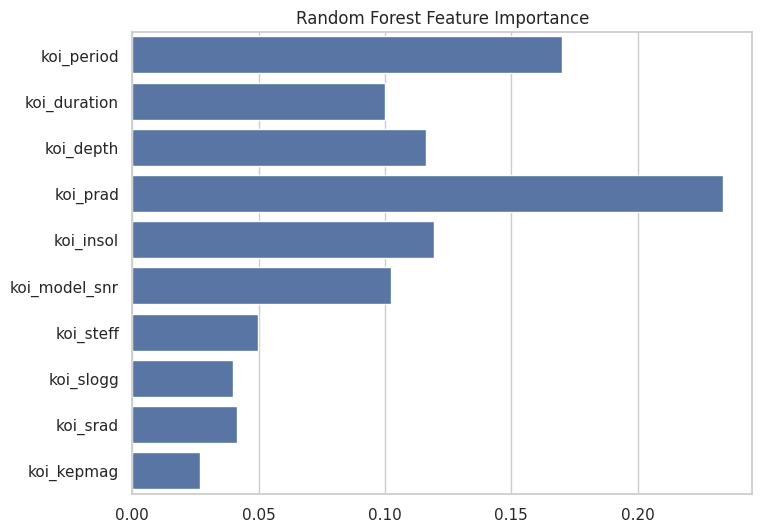

In [38]:
rf = RandomForestClassifier(random_state=42)

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20]
}

rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best RF Params:", rf_grid.best_params_)

rf = rf_grid.best_estimator_
y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

importances = rf.feature_importances_
plt.figure(figsize=(8,6))
sns.barplot(x=importances, y=features)
plt.title("Random Forest Feature Importance")
plt.show()

In [30]:
df_result = X_test.copy()
df_result['actual'] = y_test
df_result['predicted'] = y_pred_rf

def make_group(row):
    if row['actual'] == 0 and row['predicted'] == 0: return 'True Negative (TN)'
    elif row['actual'] == 0 and row['predicted'] == 1: return 'False Positive (FP)'
    elif row['actual'] == 1 and row['predicted'] == 1: return 'True Positive (TP)'
    elif row['actual'] == 1 and row['predicted'] == 0: return 'False Negative (FN)'

df_result['Confusion_Matrix'] = df_result.apply(make_group, axis=1)

student_table = df_result.groupby('Confusion_Matrix').agg(
    Count=('actual', 'count'),
    SNR_Mean=('koi_model_snr', 'mean'),
    Depth_Mean=('koi_depth', 'mean')
).reindex(['True Negative (TN)', 'False Positive (FP)', 'True Positive (TP)', 'False Negative (FN)']).round(2)


student_table = student_table.reset_index()

student_table

,Confusion_Matrix,Count,SNR_Mean,Depth_Mean
0,True Negative (TN),855,509.78,49505.38
1,False Positive (FP),150,35.42,784.39
2,True Positive (TP),781,61.54,1056.14
3,False Negative (FN),127,169.39,6376.24
